# Advanced CNN Tutorial: U-Net with a Real Dataset

**Main question:** How are the downsampling path, bottleneck, upsampling path, and skip connections **implemented** in a working U-Net?

**Dataset:** Penn–Fudan Pedestrian Segmentation  
**Task:** binary semantic segmentation — predict **person** or **background** for every pixel  
**Suggested completion time:** 1–2 hours  
**Course reference environment:** Python 3.12, PyTorch 2.11.0, TorchVision 0.26.0

This tutorial has two parts:

1. **Part 1 (Week 6): Understand the U-Net implementation.**  
   We connect every architectural component to PyTorch code and **⚠️track tensor shapes at every important step.**
2. **Part 2 (Week 7): Run a complete experiment.**  
   We download a small real dataset, train the model, validate it, test it, and visualise predictions.

You are **not** expected to write the whole network from an empty file. Your job is to read a complete implementation, identify the essential operations, calculate and understand tensor shapes, and make one small controlled change.

## Learning outcomes

By the end of this tutorial, you should be able to:

- identify the U-Net **downsampling path**, **bottleneck**, **upsampling path**, and **skip connections** in code;
- explain why segmentation needs both **semantic context** and **spatial detail**;
- track tensor shapes;
- explain why skip tensors are saved **before** pooling;
- explain how `ConvTranspose2d` changes spatial size;
- explain how `torch.cat(..., dim=1)` changes the channel dimension;
- run a complete training, validation, testing, and prediction workflow on real images.

> **The main debugging habit in this notebook:** check tensor shapes before checking anything else.

### Runtime choice: use a Colab GPU, not a TPU

In Google Colab, select:

**Runtime → Change runtime type → T4 GPU**

This notebook uses standard PyTorch with CUDA. A Colab TPU is **not** the recommended runtime for this tutorial.

If a GPU is unavailable, the notebook falls back to CPU. It should still run because the dataset and model are small, but training will be slower.

### Reading Guide

Please note the following symbols used throughout this tutorial:

- ⚠️ **Important:** This section contains key concepts or implementation details that you should read carefully and understand.
- ⏭️ **Skip the Details:** You do not need to understand the detailed syntax or implementation at this stage. Focus on the overall purpose, input, and output of the module.

Use these symbols to help you focus on the most important parts of the tutorial.

# Part 1 (Week6): How U-Net is implemented

In [3]:
# ============================================================
# 1. Imports, reproducibility, and device selection ⏭️
# ============================================================
# Usually do not reinstall PyTorch in Colab. Colab already provides a
# CUDA-compatible build. Reinstalling can create version conflicts.
#
# Course reference versions:
# Python 3.12, torch 2.11.0, torchvision 0.26.0

import copy
import os
import random
import subprocess
import sys
import time
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('TorchVision:', torchvision.__version__)

SEED = 516
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Use CUDA when Colab has allocated a GPU; otherwise use CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

if device.type != 'cuda':
    print('Recommendation: switch the Colab runtime to GPU before training.')

# Small datasets do not benefit much from many worker processes.
# num_workers=0 is also the most reliable setting across environments.
NUM_WORKERS = 0
PIN_MEMORY = device.type == 'cuda'

# Used only for automated smoke testing; you can ignore this variable.
FAST_TEST = os.environ.get('UNET_TUTORIAL_FAST_TEST', '0') == '1'

Python: 3.14.7
PyTorch: 2.13.0+cu130
TorchVision: 0.28.0+cu130
Using device: cuda


## 1.1 The segmentation task ⚠️

A classifier produces one label for an entire image. A segmentation model produces one label for **every pixel**.

For this tutorial:

- input image: `[3, 128, 128]` — RGB channels, height, width;
- target mask: `[1, 128, 128]` — one binary value per pixel;
- model output for a batch: `[B, 1, 128, 128]`;
- foreground value `1`: person;
- background value `0`: everything else.

The Penn–Fudan masks originally distinguish individual pedestrians. We simplify them into a single binary mask:

```text
any pedestrian instance  →  1
background               →  0
```

This keeps the tutorial focused on **semantic segmentation and U-Net implementation**, rather than introducing instance segmentation.

## 1.2 Download the real dataset ⏭️

Penn–Fudan is suitable for this tutorial:

- it contains only **170 real street-scene images**;
- it includes pixel-level pedestrian masks;
- its download is small enough for a Colab session;
- it is also used in an official PyTorch computer-vision tutorial.

The cell below downloads the archive only if the dataset is not already present.

In [4]:
# ============================================================
# 2. Download and extract Penn–Fudan
# ============================================================
DATA_URL = 'https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip'

# In Colab, /content is the normal working directory.
# Outside Colab, use a local folder beside the notebook.
default_data_dir = '/content/unet_data' if Path('/content').exists() else './unet_data'
DATA_DIR = Path(os.environ.get('UNET_DATA_DIR', default_data_dir))
ZIP_PATH = DATA_DIR / 'PennFudanPed.zip'
DATASET_ROOT = DATA_DIR / 'PennFudanPed'

DATA_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_ROOT.exists():
    print('Downloading Penn–Fudan...')
    try:
        # First use Python's standard downloader.
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    except Exception as first_error:
        print('Python download failed; trying wget as a fallback...')
        try:
            subprocess.run(
                ['wget', '-q', '--show-progress', DATA_URL, '-O', str(ZIP_PATH)],
                check=True,
            )
        except Exception as second_error:
            raise RuntimeError(
                'The dataset download failed. Check the internet connection and rerun this cell. '
                f'Python error: {first_error}; wget error: {second_error}'
            ) from second_error

    print('Extracting the archive...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as archive:
        archive.extractall(DATA_DIR)
else:
    print('Dataset already exists; download skipped.')

image_dir = DATASET_ROOT / 'PNGImages'
mask_dir = DATASET_ROOT / 'PedMasks'

image_paths = sorted(image_dir.glob('*.png'))
mask_paths = sorted(mask_dir.glob('*.png'))

assert len(image_paths) == len(mask_paths) > 0, 'Images and masks were not found correctly.'
print(f'Images: {len(image_paths)}')
print(f'Masks:  {len(mask_paths)}')
print('Dataset root:', DATASET_ROOT)

Extracting the archive...
Images: 170
Masks:  170
Dataset root: unet_data/PennFudanPed


## 1.3 Dataset class: keep each image and mask aligned ⏭️

Segmentation data must be transformed as a **pair**.

If the image is resized or flipped, the mask must receive the same geometric transformation. Otherwise, the foreground pixels in the mask will no longer correspond to the person in the image.

Important choices in the dataset class:

- images use **bilinear interpolation** when resized;
- masks use **nearest-neighbour interpolation**, so class labels are not averaged;
- training images may be horizontally flipped;
- mask values greater than zero are converted to foreground value `1`;
- every returned pair has shapes `[3, 128, 128]` and `[1, 128, 128]`.

The data-loading code is provided. You should understand its purpose, but you are not expected to memorise every line.

In [5]:
class PennFudanSegmentation(Dataset):
    """Return one RGB image and one binary pedestrian mask."""

    def __init__(self, root, indices, image_size=128, augment=False):
        self.root = Path(root)
        self.image_paths = sorted((self.root / 'PNGImages').glob('*.png'))
        self.mask_paths = sorted((self.root / 'PedMasks').glob('*.png'))
        self.indices = list(indices)
        self.image_size = image_size
        self.augment = augment

        if len(self.image_paths) != len(self.mask_paths):
            raise ValueError('The numbers of images and masks do not match.')

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        dataset_index = self.indices[position]

        # Load a real RGB photograph and its pixel-level annotation.
        image = Image.open(self.image_paths[dataset_index]).convert('RGB')
        mask = Image.open(self.mask_paths[dataset_index])

        # Apply the same random geometric transformation to image and mask.
        if self.augment and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # Resize all samples to one fixed size so they can form a batch.
        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )
        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST,
        )

        # Image: uint8 PIL image -> float tensor in [0, 1].
        # Shape changes from H x W x 3 to [3, H, W].
        image = TF.to_tensor(image)

        # The original mask uses 0 for background and positive integer IDs
        # for different pedestrians. For binary semantic segmentation, all
        # positive IDs become one foreground class.
        # Final mask shape: [1, H, W].
        mask = TF.pil_to_tensor(mask)
        mask = (mask > 0).float()

        return image, mask

## 1.4 Build Train-Validation-Test split ⚠️

Before training the model, we divide the dataset into three separate parts:

- **Training set:** used to train the model and update its parameters.
- **Validation set:** used during development to evaluate the model and select the best model.
- **Test set:** used only at the end to provide a final evaluation of the trained model.

Keeping these datasets separate is important because we want to evaluate how well the model performs on images that were **not used to update its parameters**.

First, we generate a **randomly shuffled list of indices** for all images in the dataset:

```python
shuffled_indices = torch.randperm(
    number_of_images,
    generator=generator
).tolist()
```

Because we use a fixed random seed, the same shuffled order can be reproduced each time the notebook is run.

Once we have the shuffled indices, we can use simple Python slicing to divide the dataset:

```python
train_indices = shuffled_indices[:120]
val_indices = shuffled_indices[120:145]
test_indices = shuffled_indices[145:]
```

Therefore:

- the first **120** shuffled images are used for training;
- the next **25** images are used for validation;
- the remaining **25** images are used for testing.

Finally, these indices are passed to the `PennFudanSegmentation` class that we defined earlier. The class loads and processes the corresponding images and segmentation masks to create:

```python
train_dataset
val_dataset
test_dataset
```

Notice that data augmentation is enabled only for the training dataset:

```python
augment=True
```

while the validation and test datasets use:

```python
augment=False
```

This is because augmentation is used to increase the variety of the training data, while the validation and test data should remain unchanged for consistent evaluation.

In [ ]:
IMAGE_SIZE = 128  # 128*128 pixels
BATCH_SIZE = 8    # 8 images per batch

number_of_images = len(image_paths)
generator = torch.Generator().manual_seed(SEED)
shuffled_indices = torch.randperm(number_of_images, generator=generator).tolist() # randomly shuffle the indices of the dataset

# 120 training images, 25 validation images, and 25 test images.
train_indices = shuffled_indices[:120]
val_indices = shuffled_indices[120:145]
test_indices = shuffled_indices[145:]

if FAST_TEST:
    train_indices = train_indices[:16]
    val_indices = val_indices[:8]
    test_indices = test_indices[:8]

train_dataset = PennFudanSegmentation(
    DATASET_ROOT, train_indices, image_size=IMAGE_SIZE, augment=True
)
val_dataset = PennFudanSegmentation(
    DATASET_ROOT, val_indices, image_size=IMAGE_SIZE, augment=False # augmentation is not applied to validation data
)
test_dataset = PennFudanSegmentation(
    DATASET_ROOT, test_indices, image_size=IMAGE_SIZE, augment=False # augmentation is not applied to test data
)

# NEVER USE TEST SET TO SELECT HYPERPARAMETERS OR MAKE DECISIONS. The test set is only for the FINAL EVALUATION of the model after all training and validation is complete.

## 1.5 DataLoader ⚠️
After creating the training, validation, and test datasets, we use PyTorch `DataLoader` objects to provide data to the model.

You can think of a `DataLoader` as a **data provider**. During training, validation, or testing, it gives us one batch of images and masks at a time.

For example, with:

```python
BATCH_SIZE = 8
```

each iteration of the `train_loader` normally provides:

```python
images   # [8, 3, 128, 128]
masks    # [8, 1, 128, 128]
```

The three DataLoaders use the corresponding datasets:

```python
train_dataset -> train_loader
val_dataset   -> val_loader
test_dataset  -> test_loader
```

Some important settings are:

- `batch_size=BATCH_SIZE`: controls how many samples are provided in each batch.
- `shuffle=True`: randomly changes the order of the training samples in each epoch.
- `shuffle=False`: keeps the validation and test data in a fixed order.
- `num_workers`: controls how many worker processes are used to load data.
- `pin_memory=True`: can make CPU-to-GPU data transfer more efficient when using a GPU.

Once a `DataLoader` is created, we can simply iterate through it:

```python
for images, masks in train_loader:
    ...
```

and it will continuously provide one batch after another until all samples in the dataset have been used.

We can also manually take one batch using:

```python
sample_images, sample_masks = next(iter(train_loader))
```

This is useful for checking the shape of the data before training the model.

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print('Training samples:  ', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Test samples:      ', len(test_dataset))

# each iteration, data loader can provide one batch of data
sample_images, sample_masks = next(iter(train_loader))
print('\nOne image batch:', tuple(sample_images.shape))   # [B, 3, 128, 128]
print('One mask batch: ', tuple(sample_masks.shape))    # [B, 1, 128, 128]

assert sample_images.ndim == 4 and sample_images.shape[1:] == (3, 128, 128)
assert sample_masks.ndim == 4 and sample_masks.shape[1:] == (1, 128, 128)

Training samples:   120
Validation samples: 25
Test samples:       25

One image batch: (8, 3, 128, 128)
One mask batch:  (8, 1, 128, 128)


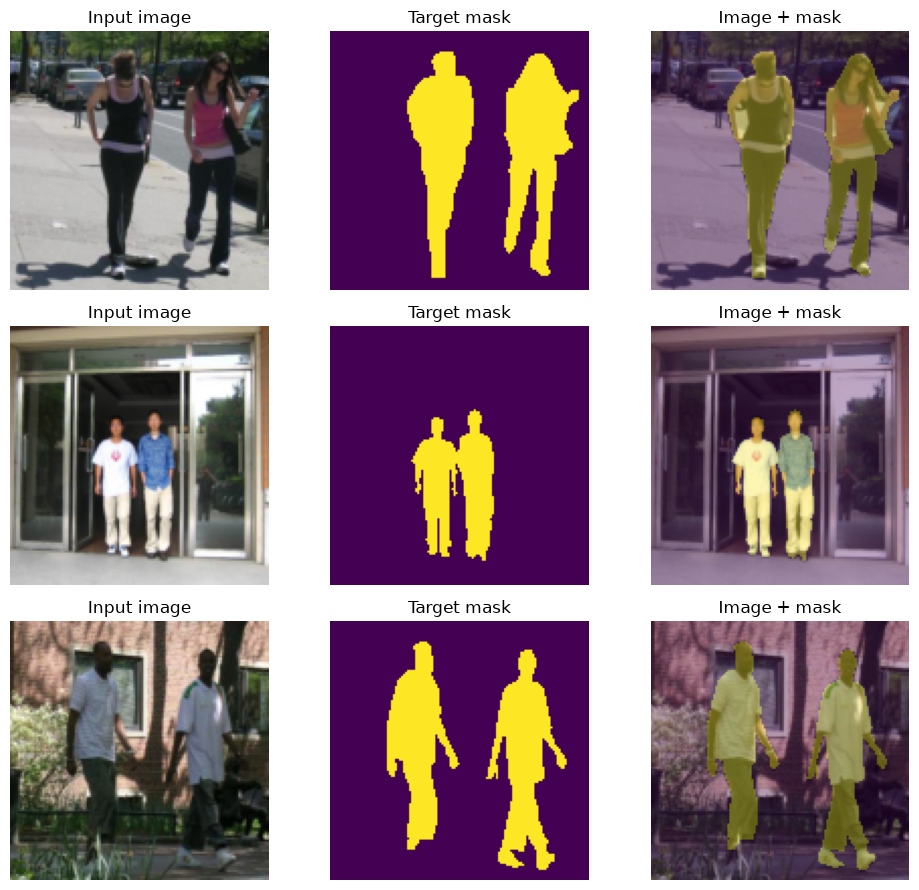

In [24]:
# Inspect real image-mask pairs before building the model.⏭️
images, masks = next(iter(train_loader))

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
for row in range(3):
    image = images[row].permute(1, 2, 0)
    mask = masks[row, 0]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title('Input image')

    axes[row, 1].imshow(mask)
    axes[row, 1].set_title('Target mask')

    axes[row, 2].imshow(image)
    axes[row, 2].imshow(mask, alpha=0.35)
    axes[row, 2].set_title('Image + mask')

    for axis in axes[row]:
        axis.axis('off')

plt.tight_layout()
plt.show()

## 1.6 The U-Net information flow (⏭️, if you understand the lecture)
The lecture described U-Net as a design for combining **semantic context** and **precise localisation**.

### Downsampling path: “what is in the image?”

At each encoder level:

1. **convolutions** extract features;
2. the feature tensor is saved for a later skip connection;
3. max pooling halves height and width.

The network gradually sees a **larger spatial context**, but pooling removes fine location detail.

### Bottleneck: the most compressed representation

The bottleneck has the smallest height and width and the largest channel count. It contains the **deepest contextual representation**.

### Upsampling path: “where should the mask be?”

At each decoder level:

1. a **transposed convolution** doubles height and width;
2. the upsampled tensor is concatenated with the matching encoder tensor;
3. convolutions combine deep context with returned spatial detail.

### Skip connections: recover information lost during downsampling

The skip tensor is saved **before pooling**, while it still has high spatial resolution. U-Net usually merges the two paths by concatenating channels:

```python
merged = torch.cat([upsampled, skip], dim=1)
```

`dim=1` is the channel dimension in `[B, C, H, W]`.

## 1.7 the complete implementation ⚠️⚠️⚠️:

`DoubleConv` applies two `3 × 3` convolutions. Padding `1` preserves height and width.

The full `CompactUNet` class below is deliberately explicit. Encoder levels, pooling operations, bottleneck, upsampling operations, concatenations, and decoder levels are written separately so that the code mirrors the architecture diagram.

Read the comments in `forward()` carefully. They show the expected tensor shape after each operation for a `128 × 128` input.

In [ ]:
class DoubleConv(nn.Module):
    """
    Apply two consecutive convolutional blocks:

        Conv2d -> BatchNorm2d -> ReLU
        Conv2d -> BatchNorm2d -> ReLU

    Both convolutions use:
        kernel_size = 3
        stride = 1
        padding = 1

    Therefore, the height and width are preserved.

    Only the number of channels may change:

        [B, in_channels, H, W]
                    ↓
        [B, out_channels, H, W]
    """

    def __init__(self, in_channels, out_channels): 
        # in_channels is the number of channels in the input tensor (3x128x128)
        # out_channels is the number of feature maps that this double convolution block will produce (e.g., 16, 32, 64, etc.)
        # the convolution block only changes the number of channels, not the height or width of the input tensor.
        """
        Parameters
        ----------
        in_channels : int
            The number of channels in the input tensor.
        out_channels : int
            The number of feature maps that this block will produce.
        """
        super().__init__()

        self.block = nn.Sequential( # defines the whole architecture of the double convolution block
            # nn.Sequential is a container that connects several layers in the
            # order in which they are listed.


            # ----------------------------------------------------------
            # First convolution
            # ----------------------------------------------------------
            # Input shape:
            #     [B, in_channels, H, W]
            # Output shape:
            #     [B, out_channels, H, W]
            nn.Conv2d(
                in_channels=in_channels, 
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,  # why?, because we want to preserve the height and width of the input tensor.
                # with kernel size 3, stride 1, and padding 1, the output height and width will be the same as the input height and width.
                # padding=1 means we add 1 pixel of zero-padding on each side of the input tensor, which ensures that the output tensor has the same spatial dimensions as the input tensor.
                bias=False, # don't need to add a bias term because batch normalisation will handle the bias automatically
            ),

            # Batch normalisation is applied independently to each
            # output channel.
            #
            # Tensor shape does not change:
            #     [B, out_channels, H, W]
            #     [B, out_channels, H, W]
            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),
            # inplace=True means that PyTorch modifies the existing
            # tensor directly instead of creating a separate output
            # tensor. This can reduce memory use.

            # ----------------------------------------------------------
            # Second convolution
            # ----------------------------------------------------------
            # Input shape:
            #     [B, out_channels, H, W]
            #
            # Output shape:
            #     [B, out_channels, H, W]
            nn.Conv2d(
                in_channels=out_channels, # the number of channels in the input tensor is now equal to the out_channels of the previous convolution
                out_channels=out_channels, # update the number of output channels to match the desired output of this block
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            nn.BatchNorm2d(out_channels), # normalise the features to make sure they have similar distributions, which helps with training stability and convergence

            nn.ReLU(inplace=True), 
        )

    def forward(self, x): # where the actual data flow is defined
        # In a PyTorch neural-network module, __init__ defines and stores the
        # layers, while forward defines how the input passes through them.
        # Therefore, __init__ describes the architecture, and forward describes
        # the data flow. Calling model(x) automatically runs forward(x).

        return self.block(x)


class CompactUNet(nn.Module):
    """A compact three-level U-Net for binary segmentation."""

    def __init__(self, in_channels=3, base_channels=16, out_channels=1):
        # in_channels is 3 because the input images are RGB (3 channels).
        # base_channels is 16 because the first convolution block will produce 16 feature maps.
        # out_channels is 1 because the output is a binary mask (1 channel).
        super().__init__()
        c = base_channels

        # -------------------------
        # Downsampling / encoder path
        # -------------------------
        # DoubleConv uses two convolutional layers with non-linear activations to fuse information across the input channels and extract more complex feature representations.
        self.encoder1 = DoubleConv(in_channels, c)       # 3   -> 16 channels, INPUT: 16 x 128 x 128, OUTPUT: 16 x 128 x 128

        # Max Pooling uses a 2x2 kernel to perform downsampling. The spatial size is halved, but the number of channels remain the same. 
        # Pooling literally "pools" the most imortant features in a local region, which helps the network focus on the most relevant information and reduces computational load. 
        self.pool1 = nn.MaxPool2d(kernel_size=2)         # 128 -> 64 pixels, OUTPUT AFTER POOLING: 16 x 64 x 64

        self.encoder2 = DoubleConv(c, 2 * c)             # 16  -> 32 channels, INPUT: 16 x 64 x 64, OUTPUT: 32 x 64 x 64
        self.pool2 = nn.MaxPool2d(kernel_size=2)         # 64  -> 32 pixels, OUTPUT AFTER POOLING: 32 x 32 x 32

        self.encoder3 = DoubleConv(2 * c, 4 * c)         # 32  -> 64 channels, INPUT: 32 x 32 x 32, OUTPUT: 64 x 32 x 32 
        self.pool3 = nn.MaxPool2d(kernel_size=2)         # 32  -> 16 pixels, OUTPUT AFTER POOLING: 64 x 16 x 16

        # -------------------------
        # Bottleneck
        # -------------------------
        # Highly compressed semantic representation of the input image.
        self.bottleneck = DoubleConv(4 * c, 8 * c)       # 64 -> 128 channels, INPUT: 64 x 16 x 16, OUTPUT: 128 x 16 x 16 - BOTTLENECK

        # -------------------------
        # Upsampling / decoder path
        # -------------------------
        # SKIP CONNECTIONS, UPSAMPLING, DECODER, CONCATENATION
        self.up3 = nn.ConvTranspose2d(8 * c, 4 * c, kernel_size=2, stride=2) # perform learnable upsampling. INPUT: 128 x 16 x 16, OUTPUT: 64 x 16 x 16
        # After concatenation: 64 decoder channels + 64 skip channels = 128.
        self.decoder3 = DoubleConv(8 * c, 4 * c) # OUTPUT AFTER DECODER3: 64 x 32 x 32 
        # up3 performs learnable upsampling, increasing the spatial size from
        #     (16 * 16) to (32 * 32) while reducing the channels from 128 to 64.
        # The result is then concatenated with the output of encoder3, not pool3.
        # After concatenation, decoder3 uses DoubleConv to fuse the upsampled
        #    decoder features with the detailed encoder features and produce 64
        #    refined feature maps.

        self.up2 = nn.ConvTranspose2d(4 * c, 2 * c, kernel_size=2, stride=2)
        # After concatenation: 32 decoder channels + 32 skip channels = 64.
        self.decoder2 = DoubleConv(4 * c, 2 * c)

        self.up1 = nn.ConvTranspose2d(2 * c, c, kernel_size=2, stride=2)
        # After concatenation: 16 decoder channels + 16 skip channels = 32.
        self.decoder1 = DoubleConv(2 * c, c)

        # A 1 x 1 convolution changes channels without changing H or W.
        # One output channel means one foreground logit per pixel.
        self.output_head = nn.Conv2d(c, out_channels, kernel_size=1)

    def forward(self, x, return_shapes=False):
        '''
        The forward method defines the actual data flow when the network runs.
        It specifies how the input passes through the previously defined modules
        and where the skip connections are applied.
        '''
        shapes = {'input': tuple(x.shape)}

        # ========================================================
        # DOWNSAMPLING PATH
        # ========================================================
        # Input: [B, 3, 128, 128]
        encoder1 = self.encoder1(x)                     # [B, 16, 128, 128]
        shapes['encoder1 (skip 1)'] = tuple(encoder1.shape)

        # Save encoder1 first, then pool it. The saved tensor keeps fine detail.
        pooled1 = self.pool1(encoder1)                  # [B, 16, 64, 64]
        shapes['pool1'] = tuple(pooled1.shape)
        # ---
        encoder2 = self.encoder2(pooled1)               # [B, 32, 64, 64]
        shapes['encoder2 (skip 2)'] = tuple(encoder2.shape)

        pooled2 = self.pool2(encoder2)                  # [B, 32, 32, 32]
        shapes['pool2'] = tuple(pooled2.shape)
        # ---
        encoder3 = self.encoder3(pooled2)               # [B, 64, 32, 32]
        shapes['encoder3 (skip 3)'] = tuple(encoder3.shape)

        pooled3 = self.pool3(encoder3)                  # [B, 64, 16, 16]
        shapes['pool3'] = tuple(pooled3.shape)

        # ========================================================
        # BOTTLENECK
        # ========================================================
        bottleneck = self.bottleneck(pooled3)           # [B, 128, 16, 16]
        shapes['bottleneck'] = tuple(bottleneck.shape)

        # ========================================================
        # UPSAMPLING PATH — DECODER LEVEL 3
        # ========================================================
        up3 = self.up3(bottleneck)                      # [B, 64, 32, 32]
        shapes['up3'] = tuple(up3.shape)

        # Before concatenation, batch size and spatial dimensions must match.
        assert up3.shape[0] == encoder3.shape[0]
        assert up3.shape[2:] == encoder3.shape[2:]

        merge3 = torch.cat([up3, encoder3], dim=1)      # [B, 128, 32, 32] # SKIP CONNECTION
        shapes['concat3'] = tuple(merge3.shape)
        decoder3 = self.decoder3(merge3)                # [B, 64, 32, 32]
        shapes['decoder3'] = tuple(decoder3.shape)

        # ========================================================
        # UPSAMPLING PATH — DECODER LEVEL 2
        # ========================================================
        up2 = self.up2(decoder3)                        # [B, 32, 64, 64]
        shapes['up2'] = tuple(up2.shape)
        assert up2.shape[2:] == encoder2.shape[2:]

        merge2 = torch.cat([up2, encoder2], dim=1)      # [B, 64, 64, 64]
        shapes['concat2'] = tuple(merge2.shape)
        decoder2 = self.decoder2(merge2)                # [B, 32, 64, 64]
        shapes['decoder2'] = tuple(decoder2.shape)

        # ========================================================
        # UPSAMPLING PATH — DECODER LEVEL 1
        # ========================================================
        up1 = self.up1(decoder2)                        # [B, 16, 128, 128]
        shapes['up1'] = tuple(up1.shape)
        assert up1.shape[2:] == encoder1.shape[2:]

        merge1 = torch.cat([up1, encoder1], dim=1)      # [B, 32, 128, 128]
        shapes['concat1'] = tuple(merge1.shape)
        decoder1 = self.decoder1(merge1)                # [B, 16, 128, 128]
        shapes['decoder1'] = tuple(decoder1.shape)

        # Raw output values are logits, not probabilities yet.
        logits = self.output_head(decoder1)             # [B, 1, 128, 128]
        shapes['output logits'] = tuple(logits.shape)

        if return_shapes:
            return logits, shapes
        return logits

### Guided code-reading checkpoint

Before running the model, answer these questions:

1. Which tensors are saved for skip connections?
2. Why are they saved before pooling?
3. Which operation halves height and width?
4. Which operation doubles height and width?
5. Why does `decoder3` receive `8 * c` input channels even though `up3` produces only `4 * c` channels?
6. Why is concatenation performed with `dim=1`?
7. Why does the output head use a `1 × 1` convolution?

<details>
<summary><strong>Check your answers</strong></summary>

1. `encoder1`, `encoder2`, and `encoder3`.
2. They still contain high-resolution spatial and boundary information before pooling removes detail.
3. `MaxPool2d(2)`.
4. `ConvTranspose2d(..., kernel_size=2, stride=2)`.
5. `up3` is concatenated with the `encoder3` skip tensor: `4c + 4c = 8c`.
6. Dimension 1 is the channel dimension in `[B, C, H, W]`.
7. It maps the final feature channels to one foreground logit per pixel without changing spatial size.

</details>

In [10]:
# ============================================================
# 4. Run a shape test before training
# ============================================================
# Create the U-Net model.
# in_channels=3: the input is an RGB image with three channels.
# base_channels=16: the first encoder level produces 16 feature maps.
# out_channels=1: binary segmentation requires one output logit per pixel.
# .to(device): move the model parameters to the selected CPU or GPU.
model = CompactUNet(in_channels=3, base_channels=16, out_channels=1).to(device)

# Create a small random tensor only for testing the network architecture.
# PyTorch image tensors use the format [B, C, H, W].
# B=2: this dummy batch contains two images.
# C=3: each image has three RGB channels.
# H=128 and W=128: each image has a spatial size of 128 x 128.
# device=device: create the tensor on the same CPU or GPU as the model.
dummy_input = torch.randn(2, 3, 128, 128, device=device)

# Switch the model to evaluation mode.
# This affects layers such as BatchNorm and Dropout.
#
# In evaluation mode, BatchNorm uses the running mean and variance
# learned during training instead of the statistics of the current batch.
# These running statistics are not updated during evaluation.
model.eval()

# This is only a forward-pass test, so gradients are not required.
# inference_mode avoids recording operations for backpropagation,
# which reduces memory use and computation.
with torch.inference_mode():
    # Calling model(dummy_input) automatically runs the forward method.
    # return_shapes=True also returns the tensor shape at each network stage.
    dummy_output, shape_trace = model(dummy_input, return_shapes=True)

print('U-Net tensor-shape trace')
print('-' * 72)
for name, shape in shape_trace.items():
    print(f'{name:24s} -> {shape}')

# A segmentation output must match the target mask shape.
assert dummy_output.shape == (2, 1, 128, 128)
print('\nShape test passed: output shape is [B, 1, H, W].')

number_of_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'Trainable parameters: {number_of_parameters:,}')

U-Net tensor-shape trace
------------------------------------------------------------------------
input                    -> (2, 3, 128, 128)
encoder1 (skip 1)        -> (2, 16, 128, 128)
pool1                    -> (2, 16, 64, 64)
encoder2 (skip 2)        -> (2, 32, 64, 64)
pool2                    -> (2, 32, 32, 32)
encoder3 (skip 3)        -> (2, 64, 32, 32)
pool3                    -> (2, 64, 16, 16)
bottleneck               -> (2, 128, 16, 16)
up3                      -> (2, 64, 32, 32)
concat3                  -> (2, 128, 32, 32)
decoder3                 -> (2, 64, 32, 32)
up2                      -> (2, 32, 64, 64)
concat2                  -> (2, 64, 64, 64)
decoder2                 -> (2, 32, 64, 64)
up1                      -> (2, 16, 128, 128)
concat1                  -> (2, 32, 128, 128)
decoder1                 -> (2, 16, 128, 128)
output logits            -> (2, 1, 128, 128)

Shape test passed: output shape is [B, 1, H, W].
Trainable parameters: 482,737


# Part 2 (Week7): A complete experiment on real images

## 2.1 From logits to a segmentation mask

The model outputs **logits** with shape `[B, 1, H, W]`. A logit is the **raw output** of the model before applying sigmoid; it **can be any real number** and represents the model's confidence before being converted into a probability.

To convert a logit \(z\) into a foreground probability \(p\), we use the sigmoid function:

$$
p = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

For visualisation and evaluation:

```python
probabilities = torch.sigmoid(logits)       # values from 0 to 1
predicted_mask = probabilities >= 0.5       # binary values 0 or 1
```

## 2.2 The loss function

During training, `BCEWithLogitsLoss` (Binary Cross-Entropy) receives the raw logits directly. It internally performs the sigmoid operation and calculates Binary Cross-Entropy:

$$
\mathcal{L}_{\mathrm{BCE}}
=
-\left[
y\log(p) + (1-y)\log(1-p)
\right]
$$

where $y \in \{0,1\}$ is the ground-truth label and $p$ is the predicted foreground probability.

We combine two loss components:

- **Binary Cross-Entropy:** checks each pixel's foreground/background prediction.
- **Soft Dice loss:** encourages overlap between the predicted foreground region and the target region. Soft Dice loss measures the overlap between the predicted foreground probabilities and the ground-truth mask, **producing a smaller loss when the two regions match more closely**.

  **Dice score** is also used as the main evaluation metric:

  - `1.0` means perfect overlap.
  - `0.0` means no overlap.

In [11]:
bce_loss = nn.BCEWithLogitsLoss()


def soft_dice_loss(logits, targets, eps=1e-6):
    """
    Soft Dice loss measures the overlap between the predicted mask and the
    ground-truth mask.

    A larger overlap gives a smaller loss, while a smaller overlap gives a
    arger loss and is penalised more.

    It is differentiable, so gradients can be computed through it and the
    network can be trained using backpropagation.
    """
    probabilities = torch.sigmoid(logits)

    # Sum over channel, height, and width; keep one score per image.
    dimensions = (1, 2, 3)
    intersection = (probabilities * targets).sum(dim=dimensions)
    total = probabilities.sum(dim=dimensions) + targets.sum(dim=dimensions)

    dice = (2.0 * intersection + eps) / (total + eps)
    return 1.0 - dice.mean()


def segmentation_loss(logits, targets):
    return bce_loss(logits, targets) + soft_dice_loss(logits, targets)

### 2.3 Evaluation metric
  Dice score is an evaluation metric that **measures the overlap between
  the predicted binary mask and the ground-truth mask.**

  A higher Dice score means better overlap, with 1.0 representing perfect
  overlap. Unlike Soft Dice loss, this metric is **non-differentiable** because the prediction is converted into a binary mask using a threshold, so it is used **only for evaluation/reporting, not for backpropagation**.

In [12]:
@torch.inference_mode()
def dice_score(logits, targets, threshold=0.5, eps=1e-6):

    predictions = (torch.sigmoid(logits) >= threshold).float()
    dimensions = (1, 2, 3)

    intersection = (predictions * targets).sum(dim=dimensions)
    total = predictions.sum(dim=dimensions) + targets.sum(dim=dimensions)
    scores = (2.0 * intersection + eps) / (total + eps)
    return scores.mean().item()

# @ is Python's decorator syntax. Here, @torch.inference_mode()
# applies inference mode to the entire dice_score function automatically.
# Therefore, whenever this function is called, PyTorch disables gradient
# tracking because this function is only used for evaluation, not optimisation.

## 2.3 Training, validation, and testing

A complete experiment separates the data into three roles:

- **training set:** updates model parameters;
- **validation set:** checks performance during development and selects the best epoch;
- **test set:** evaluates the selected model once at the end.

The training order for one batch is (Important):

```text
clear old gradients
→ forward pass
→ calculate loss
→ backward pass
→ update parameters
```

During validation and testing:

- call `model.eval()`;
- do not calculate gradients;
- do not update model parameters.

In [13]:
def run_epoch(model, loader, optimizer=None):
    """
    Run one training epoch or one evaluation epoch.

    model: is the neural network being trained or evaluated
    (here, our CompactUNet model).

    loader: can be train_loader, val_loader, or test_loader.

    If an optimizer is provided, the function performs training;
    if optimizer=None, it performs evaluation only.
    """
    training = optimizer is not None
    model.train(training)  # training = True or False?

    total_loss = 0.0
    total_dice = 0.0
    total_samples = 0

    for images, masks in loader:
        # FOR EACH BATCH...

        # Move the entire batch to the same device as the model.
        images = images.to(device, non_blocking=True)   # [B, 3, 128, 128]
        masks = masks.to(device, non_blocking=True)     # [B, 1, 128, 128]

        if training:
            # In pytorch, Gradients accumulate by default, so clear the previous
            # batch first! This is a very important step in training!!
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            # Step 1: Forward pass
            # Pass the input images through the model to obtain one logit per pixel.
            logits = model(images)

            # Step 2: Calculate the loss
            # Compare the predicted logits with the ground-truth masks.
            loss = segmentation_loss(logits, masks)

            if training:
                # Step 3: Backward pass
                # Compute the gradients of the loss with respect to all trainable parameters.
                loss.backward()

                # Step 4: Update the model parameters
                # Use the optimizer and the computed gradients to update the network weights.
                optimizer.step()

        batch_size = images.size(0)

        # loss.item() is the average loss of this batch, so multiply by batch_size
        # to convert it back to the total loss contributed by this batch.
        total_loss += loss.item() * batch_size

        total_dice += dice_score(logits.detach(), masks) * batch_size
        total_samples += batch_size

        # Question for you: For validation or testing, we call `run_epoch()` without an optimizer.
        # What happens during an evaluation epoch when `optimizer=None`?

    return total_loss / total_samples, total_dice / total_samples

In [14]:
# Now that the model, loss functions, evaluation metric, and training/evaluation
# procedure are ready, we can finally train the U-Net model!

model = CompactUNet(in_channels=3, base_channels=16, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# If FAST_TEST=True, run only 1 epoch for a quick test;
# otherwise, run the full training for 15 epochs.
EPOCHS = 1 if FAST_TEST else 15

history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}

best_validation_dice = -1.0
best_state = None

start_time = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)

    if val_dice > best_validation_dice:
        best_validation_dice = val_dice

        best_state = copy.deepcopy(model.state_dict())
        # Save a copy of the model parameters when the current validation
        # Dice score is the best seen so far.
        # deepcopy creates an independent snapshot because the model parameters
        # will continue to change during later epochs.

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
        f'train Dice {train_dice:.3f} | val Dice {val_dice:.3f}'
    )

elapsed = time.perf_counter() - start_time
print(f'\nTraining time: {elapsed:.1f} seconds')
print(f'Best validation Dice: {best_validation_dice:.3f}')

# Restore the parameters from the best validation epoch.
model.load_state_dict(best_state)

Epoch 01/15 | train loss 1.2852 | val loss 1.3212 | train Dice 0.443 | val Dice 0.000
Epoch 02/15 | train loss 1.1192 | val loss 1.2610 | train Dice 0.620 | val Dice 0.035
Epoch 03/15 | train loss 1.0325 | val loss 1.0021 | train Dice 0.659 | val Dice 0.566
Epoch 04/15 | train loss 0.9405 | val loss 0.9683 | train Dice 0.699 | val Dice 0.647
Epoch 05/15 | train loss 0.8843 | val loss 0.8985 | train Dice 0.708 | val Dice 0.654
Epoch 06/15 | train loss 0.8234 | val loss 0.8658 | train Dice 0.720 | val Dice 0.680
Epoch 07/15 | train loss 0.7624 | val loss 0.8384 | train Dice 0.742 | val Dice 0.673
Epoch 08/15 | train loss 0.7228 | val loss 0.7857 | train Dice 0.756 | val Dice 0.684
Epoch 09/15 | train loss 0.6684 | val loss 0.7707 | train Dice 0.769 | val Dice 0.697
Epoch 10/15 | train loss 0.6124 | val loss 0.7555 | train Dice 0.789 | val Dice 0.678
Epoch 11/15 | train loss 0.5977 | val loss 0.7242 | train Dice 0.778 | val Dice 0.703
Epoch 12/15 | train loss 0.5400 | val loss 0.7330 | tr

<All keys matched successfully>

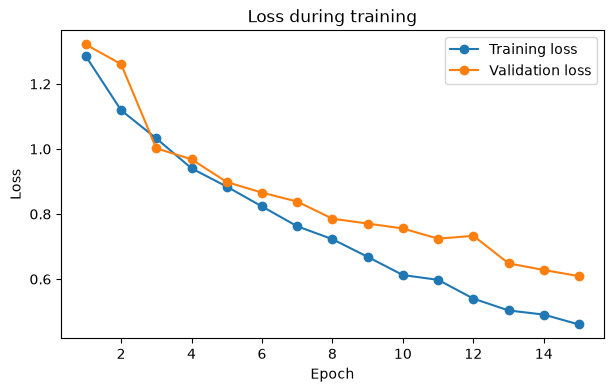

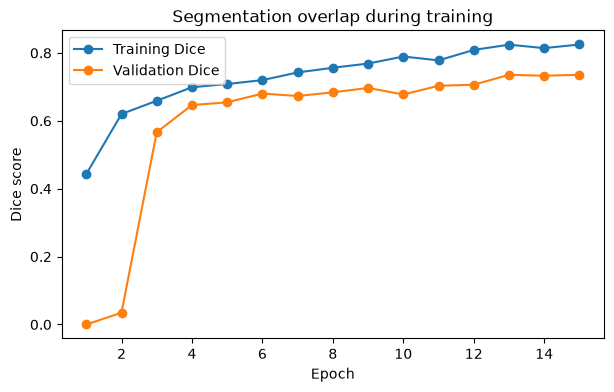

In [15]:
# Plot learning curves. The exact values vary slightly between runs.
epoch_numbers = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epoch_numbers, history['train_loss'], marker='o', label='Training loss')
plt.plot(epoch_numbers, history['val_loss'], marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epoch_numbers, history['train_dice'], marker='o', label='Training Dice')
plt.plot(epoch_numbers, history['val_dice'], marker='o', label='Validation Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice score')
plt.title('Segmentation overlap during training')
plt.legend()
plt.show()

## 2.4 Test the selected model and inspect predictions

A numerical score is useful, but segmentation results should also be viewed.

For each test example, we display:

1. the real input image;
2. the ground-truth mask;
3. the predicted foreground probability;
4. the thresholded binary prediction;
5. the prediction overlaid on the image.

Look for both successes and errors:

- Does the model find the correct person?
- Are boundaries accurate?
- Does it incorrectly include background objects?
- Does it miss small or partially occluded pedestrians?

Test loss: 0.5355
Test Dice: 0.766


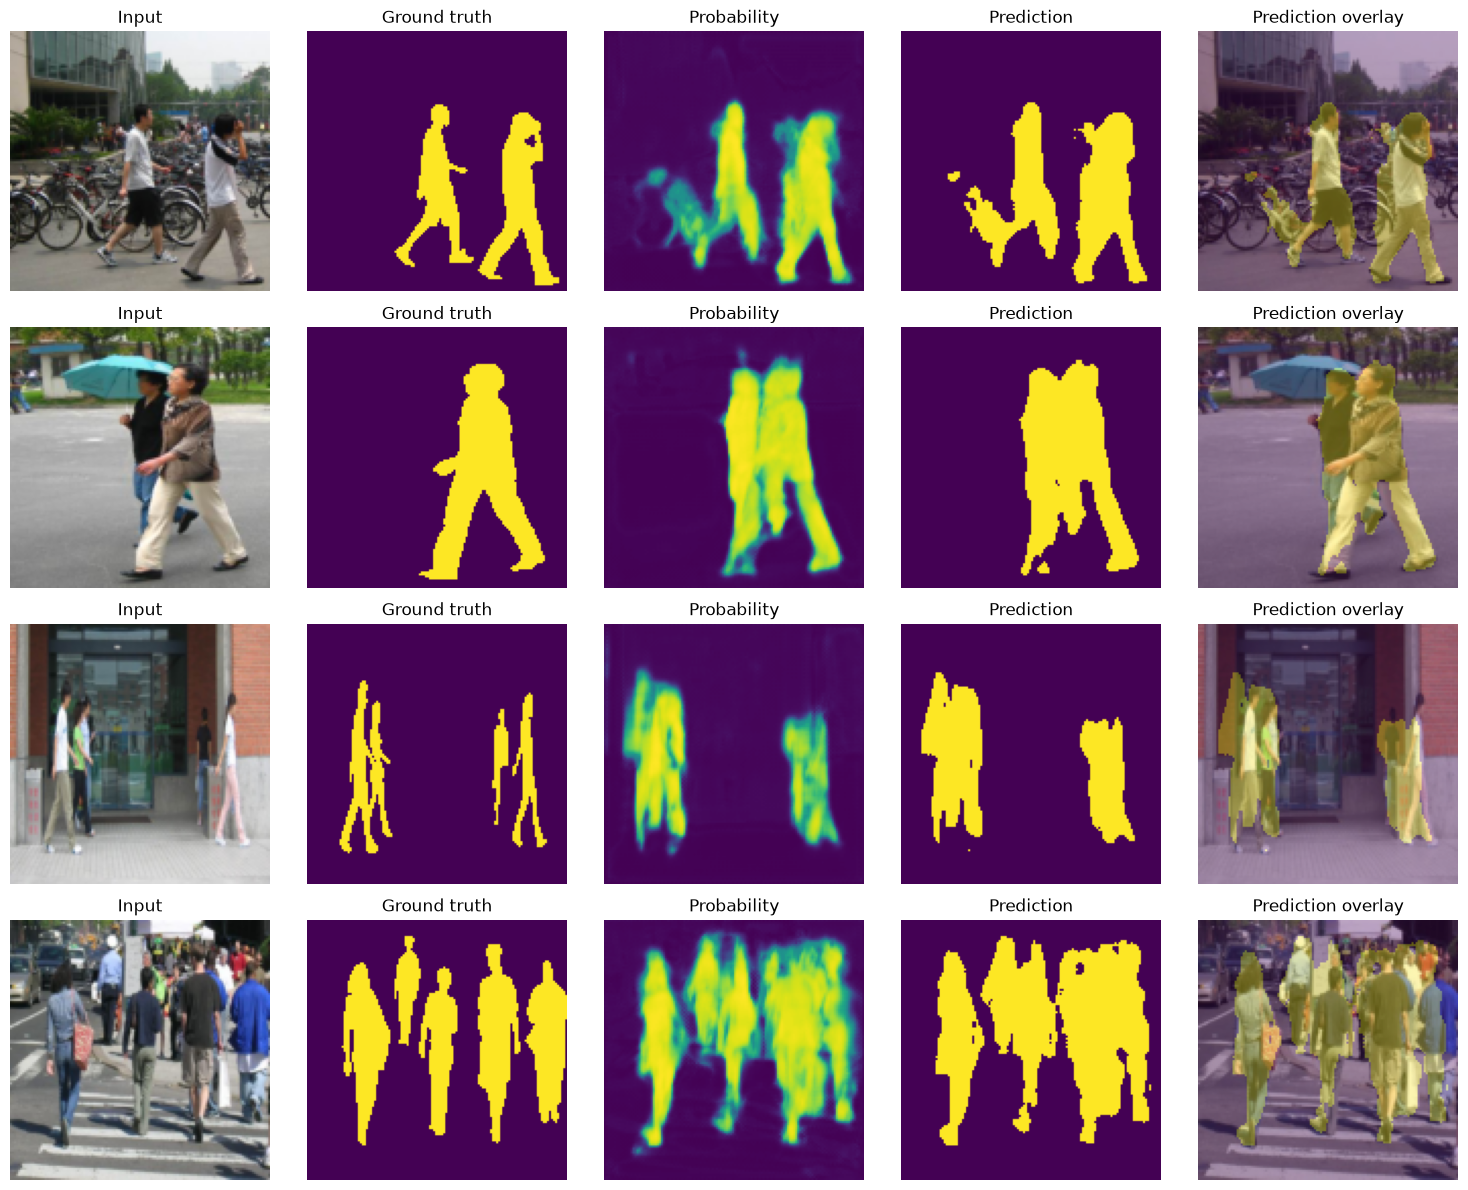

In [16]:
# Final numerical evaluation on the test set.

# Here, we use the best state model during training.
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print(f'Test loss: {test_loss:.4f}')
print(f'Test Dice: {test_dice:.3f}')

# Visualise a small batch from the unseen test set.
model.eval()
# Create an iterator from test_loader and take one batch of test images and
# their corresponding ground-truth masks.
test_images, test_masks = next(iter(test_loader))

with torch.inference_mode():
    test_logits = model(test_images.to(device))
    test_probabilities = torch.sigmoid(test_logits).cpu()

threshold = 0.5
test_predictions = (test_probabilities >= threshold).float()

number_to_show = min(4, test_images.size(0))
fig, axes = plt.subplots(number_to_show, 5, figsize=(15, 3 * number_to_show))

for row in range(number_to_show):
    image = test_images[row].permute(1, 2, 0)
    target = test_masks[row, 0]
    probability = test_probabilities[row, 0]
    prediction = test_predictions[row, 0]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title('Input')

    axes[row, 1].imshow(target)
    axes[row, 1].set_title('Ground truth')

    axes[row, 2].imshow(probability)
    axes[row, 2].set_title('Probability')

    axes[row, 3].imshow(prediction)
    axes[row, 3].set_title('Prediction')

    axes[row, 4].imshow(image)
    axes[row, 4].imshow(prediction, alpha=0.35)
    axes[row, 4].set_title('Prediction overlay')

    for axis in axes[row]:
        axis.axis('off')

plt.tight_layout()
plt.show()

## 2.5 One small controlled modification: change the threshold

The model produces probabilities. The threshold decides which pixels become foreground.

Try changing:

```python
threshold = 0.5
```

to `0.3` or `0.7`, then rerun only the prediction visualisation.

- A lower threshold usually predicts more foreground pixels.
- A higher threshold usually predicts fewer foreground pixels.
- The network architecture and trained weights do not change.

This is an example of modifying an existing workflow without rebuilding the model.

## 2.6 Final understanding check

Answer these questions without running new code:

1. Why must an input size be divisible by 8 in this three-level U-Net?
2. Which three tensors carry high-resolution information from encoder to decoder?
3. What happens to height and width after each `MaxPool2d(2)`?
4. What happens to height and width after each transposed convolution?
5. Immediately before `decoder3`, why are there 128 channels?
6. Which dimensions must match before `torch.cat([up3, encoder3], dim=1)`?
7. Why must the final output shape match the target-mask shape?
8. What is the difference between logits, probabilities, and a binary mask?

<details>
<summary><strong>Answers</strong></summary>

1. Three pooling operations divide each spatial dimension by \(2^3=8\).
2. `encoder1`, `encoder2`, and `encoder3`.
3. They are halved.
4. They are doubled.
5. `up3` has 64 channels and `encoder3` has 64 channels; concatenation gives 128.
6. Batch size, height, and width must match. Channels are allowed to differ because channel is the concatenation dimension.
7. The model must produce one prediction for each target pixel so that loss can compare corresponding locations.
8. Logits are unrestricted raw outputs; sigmoid converts them to probabilities; thresholding converts probabilities to a binary mask.

</details>

# References

- Ronneberger, Fischer, and Brox, *U-Net: Convolutional Networks for Biomedical Image Segmentation*.
- PyTorch, *TorchVision Object Detection Finetuning Tutorial* — source and description of the Penn–Fudan dataset.
- Penn–Fudan Pedestrian Database, University of Pennsylvania and Fudan University.